## SVM Liear EDA

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC

seed = 1234
np.random.seed(seed)


In [7]:
x1, y1 = make_classification(n_samples=100, #생성할 데이터 수
                             n_features=2, # 사용할 특성의 수
                             n_redundant=0, # 중복 특성 수
                             n_clusters_per_class=1, # 클래스 당 클러스터 수
                             flip_y=0, # 클래스 레이블이 뒤바꿜 확률
                             class_sep=2, # 클래스 간 분리도, 높을수록 분리가 잘 됨
                             random_state=5)

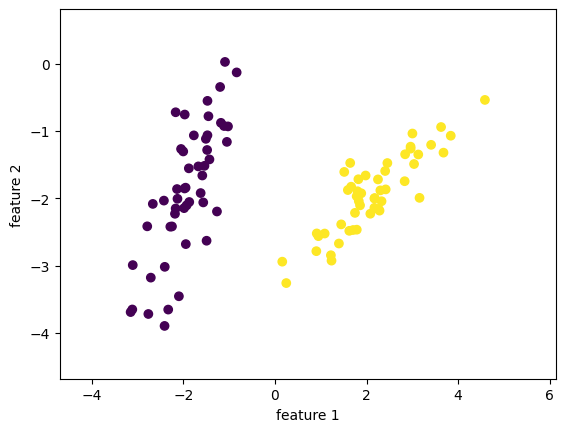

In [13]:
plt.scatter(x1[:, 0], x1[:, 1], c=y1)
plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.margins(0.2)


In [14]:
# Hard Margin SVM

svm_hard_margin = SVC(kernel="linear", C=100)
svm_hard_margin.fit(x1, y1)


SVC(C=100, kernel='linear')

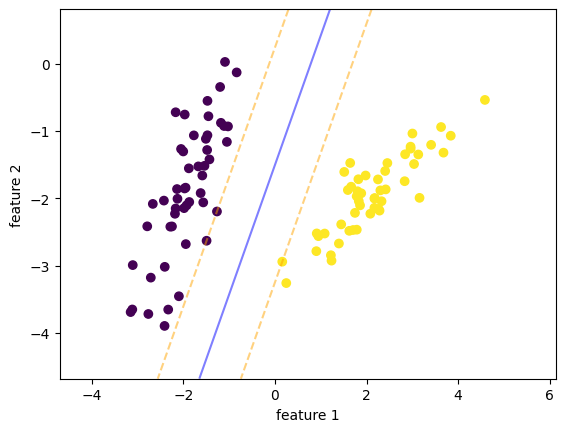

In [22]:
plt.scatter(x1[:, 0], x1[:, 1],  c=y1)

plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.margins(0.2)

xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                     np.linspace(ylim[0], ylim[1], 50))

Z = svm_hard_margin.decision_function(np.column_stack((xx.ravel(), yy.ravel())))

Z = Z.reshape(xx.shape)

plt.contour(xx, yy, # in space(xx, yy)
                Z, # plot Z
                levels=[-1, 0, 1], # that z are -1, 0, 1
                colors = ['orange', 'blue', 'orange'],
                alpha=0.5,
                linestyles=['--', '-', '--'])


In [28]:
# Soft Margin SVM

x2, y2 = make_classification(n_samples=100,
                             n_features=2,
                             n_redundant=0,
                             n_clusters_per_class=1,
                             flip_y=0.06,
                             class_sep=1.5,
                             random_state=5)


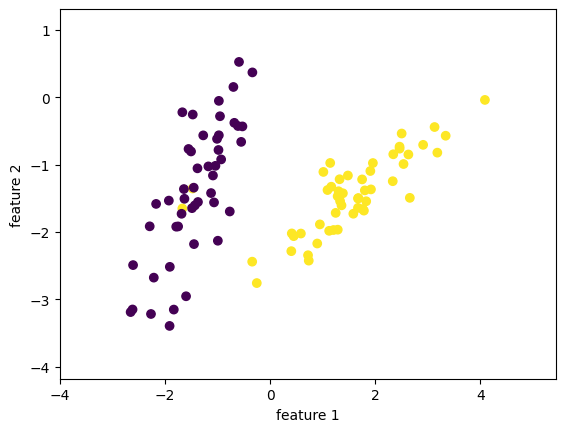

In [29]:
plt.scatter(x2[:, 0], x2[:, 1], c=y2)
plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.margins(0.2)

In [30]:
svm_soft_margin = SVC(kernel='linear', C=0.1)
svm_soft_margin.fit(x2, y2)

SVC(C=0.1, kernel='linear')

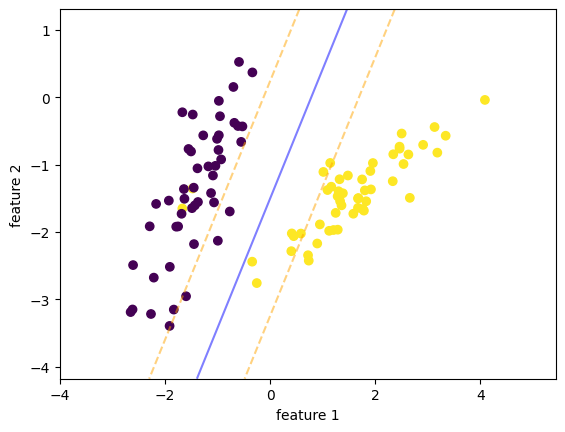

In [31]:
plt.scatter(x2[:, 0], x2[:, 1],  c=y2)

plt.xlabel("feature 1")
plt.ylabel("feature 2")

plt.margins(0.2)

xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                     np.linspace(ylim[0], ylim[1], 50))

Z = svm_hard_margin.decision_function(np.column_stack((xx.ravel(), yy.ravel())))

Z = Z.reshape(xx.shape)

plt.contour(xx, yy, # in space(xx, yy)
                Z, # plot Z
                levels=[-1, 0, 1], # that z are -1, 0, 1
                colors = ['orange', 'blue', 'orange'],
                alpha=0.5,
                linestyles=['--', '-', '--'])


-The higher the C, the higher the tendency to completely separate. That means hard margin.

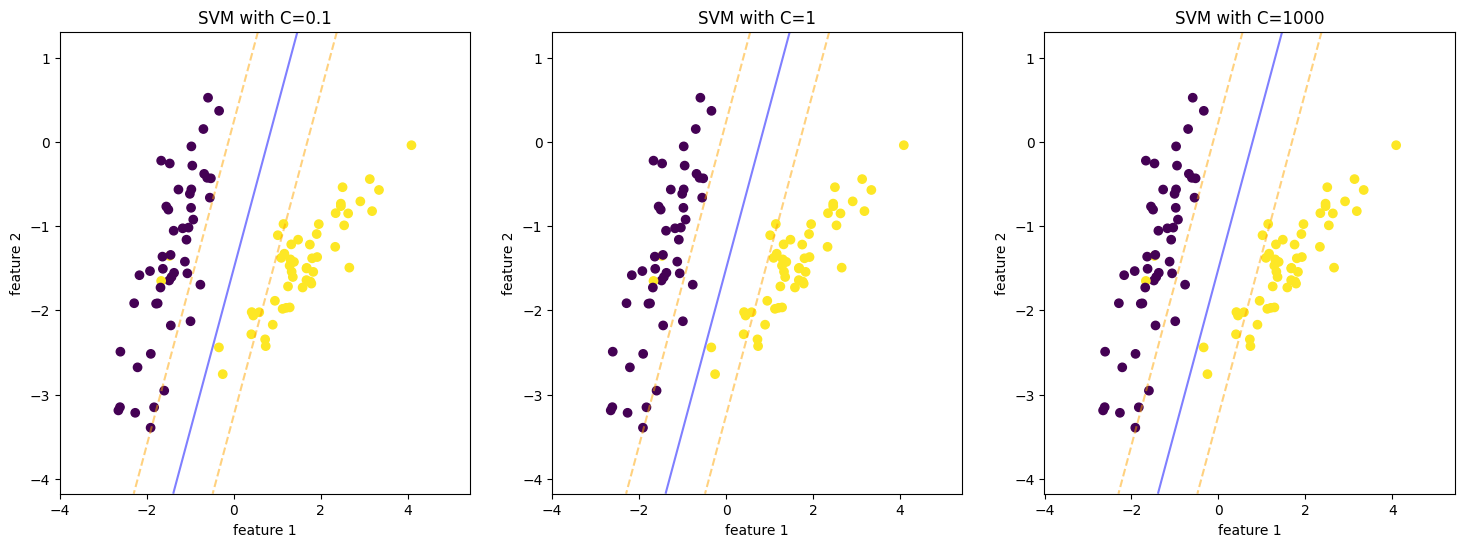

In [35]:
def plot_svm(svm_model, X, y, title):
  svm_model.fit(X, y)
  plt.scatter(X[:, 0], X[:, 1], c=y)

  plt.xlabel("feature 1")
  plt.ylabel("feature 2")

  plt.margins(0.2)

  xlim = plt.gca().get_xlim()
  ylim = plt.gca().get_ylim()

  xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                      np.linspace(ylim[0], ylim[1], 50))

  Z = svm_hard_margin.decision_function(np.column_stack((xx.ravel(), yy.ravel())))

  Z = Z.reshape(xx.shape)

  plt.contour(xx, yy, # in space(xx, yy)
                  Z, # plot Z
                  levels=[-1, 0, 1], # that z are -1, 0, 1
                  colors = ['orange', 'blue', 'orange'],
                  alpha=0.5,
                  linestyles=['--', '-', '--'])
  plt.title(title)


svm_c_0_1 = SVC(kernel='linear', C=0.1)
svm_c_1 = SVC(kernel='linear', C=1)
svm_c_1000 = SVC(kernel='linear', C=1000)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_svm(svm_c_0_1, x2, y2, "SVM with C=0.1")

plt.subplot(1, 3, 2)
plot_svm(svm_c_1, x2, y2, "SVM with C=1")

plt.subplot(1, 3, 3)
plot_svm(svm_c_1000, x2, y2, "SVM with C=1000")

- The higher C, the smaller the margin area.